# Fine-Tuning Training

# Libraries

In [23]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.losses import CoSENTLoss, MatryoshkaLoss
from datasets import Dataset
from peft import LoraConfig, TaskType
import xgboost as xgb
import torch

In [8]:
import os
# This enables memory fragmentation handling specifically for AMD HIP
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

In [9]:
import torch
# function to see gpu usage
def print_gpu_utilization():
    if not torch.cuda.is_available():
        print("No GPU detected.")
        return
    
    reserved = torch.cuda.memory_reserved()
    allocated = torch.cuda.memory_allocated()
    total_memory = torch.cuda.get_device_properties(0).total_memory
    
    print(f"Total GPU Mem: {total_memory / 1024**3:.2f} GB")
    print(f"Reserved (Cached): {reserved / 1024**3:.2f} GB")
    print(f"Allocated (Active): {allocated / 1024**3:.2f} GB")
    print(f"Free (Approx): {(total_memory - reserved) / 1024**3:.2f} GB")
    print("-" * 30)

# Run it
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 0.00 GB
Allocated (Active): 0.00 GB
Free (Approx): 15.82 GB
------------------------------


# Data Import, Clean, and Sample

In [10]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load in freMTPL2freq dataset
dataset = fetch_openml(data_id=41214, as_frame=True)
full_df = dataset.frame

# Clean basic types first
full_df['ClaimNb'] = pd.to_numeric(full_df['ClaimNb'])
full_df['Exposure'] = pd.to_numeric(full_df['Exposure'])
full_df['Exposure'] = full_df['Exposure'].clip(upper=1.0)
full_df['Frequency'] = full_df['ClaimNb'] / full_df['Exposure']

# mapping for contextualized factors
brand_mapping = {'B1': 'Renault, Nissan, or Citroen', 'B2': 'Renault, Nissan, or Citroen',
                 'B3': 'Volkswagen, Audi, Skoda, or Seat', 'B4': 'Opel, General Motors, or Ford',
                 'B5': 'Opel, General Motors, or Ford','B6': 'Fiat', 'B10':'Mercedes, Chrysler, or BMW',
                 'B11':'Mercedes, Chrysler, or BMW', 'B12': 'Japanese (except Nissan) or Korean', 'B13': 'Other','B14': 'Other' }

region_mapping = {
    "R11": "Île-de-France",
    "R21": "Champagne-Ardenne",
    "R22": "Picardie",
    "R23": "Haute-Normandie",
    "R24": "Centre",
    "R25": "Basse-Normandie",
    "R26": "Bourgogne",
    "R31": "Nord–Pas-de-Calais",
    "R41": "Lorraine",
    "R42": "Alsace",
    "R43": "Franche–Comté",
    "R52": "Pays de la Loire",
    "R53": "Bretagne",
    "R54": "Poitou–Charentes",
    "R72": "Aquitaine",
    "R73": "Midi–Pyrénées",
    "R74": "Limousin",
    "R82": "Rhône–Alpes",
    "R83": "Auvergne",
    "R91": "Languedoc–Roussillon",
    "R93": "Provence–Alpes–Côte d’Azur",
    "R94": "Corse"
}

area_mapping = {
    "A": "rural area",
    "B": "semi-rural area",
    "C": "suburban-fringe area",
    "D": "suburban area",
    "E": "urban area",
    "F": "urban center"
}

gas_mapping = {
    "'Diesel'": "Diesel",
    "'Regular'": "Regular"

}

full_df["VehBrand"] = full_df["VehBrand"].map(brand_mapping)
full_df["Region"] = full_df["Region"].map(region_mapping)
full_df["Area"] = full_df["Area"].map(area_mapping)
full_df["VehGas"] = full_df["VehGas"].map(gas_mapping)


In [11]:
# Load the split indices
df_splits = pd.read_csv('freMTPL2freq_split_indices.csv')

# Ensure IDpol is the same type in both dataframes for a clean merge
full_df['IDpol'] = full_df['IDpol'].astype(int)
df_splits['IDpol'] = df_splits['IDpol'].astype(int)

# Merge the dataset with the split indicators
# We use a left join to keep the original data rows
df_merged = full_df.merge(df_splits, on='IDpol', how='left')

# Create the subsets based on the indicator columns
train_df = df_merged[df_merged['is_train'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
test_df = df_merged[df_merged['is_test'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
finetune_df = df_merged[df_merged['is_finetune'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()

# Print results
print(f"Total rows: {len(full_df)}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Finetune rows: {len(finetune_df)}")

# Inspect the training set
print(train_df.head())

Total rows: 678013
Train rows: 500000
Test rows: 100000
Finetune rows: 76782
   IDpol  ClaimNb  Exposure                  Area  VehPower  VehAge  DrivAge  \
1      3        1      0.77         suburban area         5       0       55   
3     10        1      0.09       semi-rural area         7       0       46   
4     11        1      0.84       semi-rural area         7       0       46   
5     13        1      0.52            urban area         6       2       38   
7     17        1      0.27  suburban-fringe area         7       0       33   

   BonusMalus                            VehBrand   VehGas  Density  \
1          50  Japanese (except Nissan) or Korean  Regular     1217   
3          50  Japanese (except Nissan) or Korean   Diesel       76   
4          50  Japanese (except Nissan) or Korean   Diesel       76   
5          50  Japanese (except Nissan) or Korean  Regular     3003   
7          68  Japanese (except Nissan) or Korean   Diesel      137   

               

In [12]:
train_df

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,Frequency
1,3,1,0.77000,suburban area,5,0,55,50,Japanese (except Nissan) or Korean,Regular,1217,Rhône–Alpes,1.298701
3,10,1,0.09000,semi-rural area,7,0,46,50,Japanese (except Nissan) or Korean,Diesel,76,Aquitaine,11.111111
4,11,1,0.84000,semi-rural area,7,0,46,50,Japanese (except Nissan) or Korean,Diesel,76,Aquitaine,1.190476
5,13,1,0.52000,urban area,6,2,38,50,Japanese (except Nissan) or Korean,Regular,3003,Nord–Pas-de-Calais,1.923077
7,17,1,0.27000,suburban-fringe area,7,0,33,68,Japanese (except Nissan) or Korean,Diesel,137,Languedoc–Roussillon,3.703704
...,...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326,0,0.00274,urban area,4,0,54,50,Japanese (except Nissan) or Korean,Regular,3317,Provence–Alpes–Côte d’Azur,0.000000
678009,6114327,0,0.00274,urban area,4,0,41,95,Japanese (except Nissan) or Korean,Regular,9850,Île-de-France,0.000000
678010,6114328,0,0.00274,suburban area,6,2,45,50,Japanese (except Nissan) or Korean,Diesel,1323,Rhône–Alpes,0.000000
678011,6114329,0,0.00274,semi-rural area,4,0,60,50,Japanese (except Nissan) or Korean,Regular,95,Bourgogne,0.000000


# Create Prompts

In [13]:
# ==========================================
# 2. SERIALIZATION (Tabular -> Text)
# ==========================================
def serialize_row(row):
    """
    Converts a row of insurance covariates into a natural language prompt.
    Uses a fixed template for consistency between Training and Inference.
    """
    # Handling categorical values cleanly
    veh_brand = str(row['VehBrand']).strip()
    veh_gas = str(row['VehGas']).strip()
    area = str(row['Area']).strip()
    region = str(row['Region']).strip()
    
    return (
        f"A policyholder is {row['DrivAge']} years old living in a {area} of {region}, France with a population density {row['Density']} people/km2. "
        f"They drive a {veh_brand} vehicle which runs on {veh_gas} fuel with a vehicle power class of {row['VehPower']} (min = 4, max = 15). "
        f"The vehicle age is {row['VehAge']} years and the driver's bonus-malus score is {row['BonusMalus']} (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)."
    )

# Apply serialization
print("Serializing rows to text...")
train_df['text_desc'] = train_df.apply(serialize_row, axis=1)
test_df['text_desc'] = test_df.apply(serialize_row, axis=1)

Serializing rows to text...


In [14]:
import random
import pandas as pd

# Generate different templates for finetuning dataset
def get_clean_variables(row):
    return {
        "driv_age": row['DrivAge'],
        "area": row.get('Area', 'Unknown'),       
        "region": row.get('Region', 'Unknown'),   
        "density": row['Density'],
        "veh_brand": row.get('VehBrand', 'Unknown'),
        "veh_gas": row.get('VehGas', 'Unknown'),
        "veh_power": row['VehPower'],
        "veh_age": row['VehAge'],
        "bonus": row['BonusMalus']
    }

# --- TEMPLATE 1: The Narrative ---
def template_narrative(v):
    return (
        f"You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information. "
        f"A policyholder is {v['driv_age']} years old living in a {v['area']} of {v['region']}, France with a population density {v['density']} people/km2. "
        f"They drive a {v['veh_brand']} vehicle which runs on {v['veh_gas']} fuel with a vehicle power class of {v['veh_power']} (min = 4, max = 15). "
        f"The vehicle age is {v['veh_age']} years and the driver's bonus-malus score is {v['bonus']} (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)."
    )

# --- TEMPLATE 2: The Analytical ---
def template_analytical(v):
    return (
        f"You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information. "
        f"RISK PROFILE: Driver Age: {v['driv_age']} | Bonus-Malus: {v['bonus']} | Region: {v['region']} ({v['area']}). "
        f"VEHICLE DATA: Brand: {v['veh_brand']} | Fuel: {v['veh_gas']} | Power: {v['veh_power']} | Age: {v['veh_age']} years. "
        f"ENVIRONMENT: Density {v['density']} per km2."
    )

# --- TEMPLATE 3: The Vehicle-First ---
def template_reversed(v):
    return (
        f"You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information. "
        f"Insured Vehicle: A {v['veh_age']}-year-old {v['veh_brand']} ({v['veh_gas']} fuel, Power Class {v['veh_power']}). "
        f"Operated by a {v['driv_age']}-year-old driver with a bonus-malus score of {v['bonus']}. "
        f"Location: {v['region']} ({v['area']} zone), Density: {v['density']}."
    )

# List of all templates
# Select which templates you want the finetuning data to follow
templates = [template_narrative]

# 2. Generate the Augmented Dataset
augmented_texts = []
augmented_labels = [] 
augmented_weights = []

# Loop through original dataframe
for idx, row in finetune_df.iterrows():
    # Pre-calculate variables once
    vars_dict = get_clean_variables(row)
    
    # Target variables (ClaimNb, Exposure)
    label = row['ClaimNb'] 
    weight = row['Exposure']
    
    # Apply ALL templates to every row
    for func in templates:
        augmented_texts.append(func(vars_dict))
        augmented_labels.append(label)
        augmented_weights.append(weight)

# 3. Create the new Training DataFrame
# This dataframe is now 3x larger than original
finetune_df_aug = pd.DataFrame({
    'text_desc': augmented_texts,
    'ClaimNb': augmented_labels,
    'Exposure': augmented_weights
})

print(f"Original Size: {len(finetune_df)}")
print(f"Augmented Size: {len(finetune_df_aug)}")
print("Sample:", finetune_df_aug['text_desc'].iloc[1]) # Check the second template

Original Size: 76782
Augmented Size: 76782
Sample: You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information. A policyholder is 44 years old living in a urban center of Île-de-France, France with a population density 27000 people/km2. They drive a Japanese (except Nissan) or Korean vehicle which runs on Regular fuel with a vehicle power class of 9 (min = 4, max = 15). The vehicle age is 0 years and the driver's bonus-malus score is 76 (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus).


In [15]:
# check finetuning dataset
finetune_df_aug

,text_desc,ClaimNb,Exposure
0,You are an auto insurance underwriter. Evaluat...,1,0.750000
1,You are an auto insurance underwriter. Evaluat...,1,0.340000
2,You are an auto insurance underwriter. Evaluat...,1,0.100000
3,You are an auto insurance underwriter. Evaluat...,2,0.810000
4,You are an auto insurance underwriter. Evaluat...,1,0.050000
...,...,...,...
76777,You are an auto insurance underwriter. Evaluat...,0,0.010000
76778,You are an auto insurance underwriter. Evaluat...,0,0.010000
76779,You are an auto insurance underwriter. Evaluat...,0,0.008219
76780,You are an auto insurance underwriter. Evaluat...,0,0.005479


### Example Prompt

A policyholder is 35 years old living in a suburban-fringe area of Poitou–Charentes, France with a population density 233 people/km2. They drive a Opel, General Motors, or Ford vehicle which runs on Diesel fuel with a vehicle power class of 5 (min = 4, max = 15). The vehicle age is 7 years and the driver's bonus-malus score is 50 (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus).

# Pair Generation

In [16]:
# ==========================================
# 3. PAIR GENERATION (Metric Learning)
# ==========================================
def generate_pairs(dataframe, num_pairs=150000):
    # Calculate Frequency on the fly

    df = dataframe.copy()
    df['Frequency'] = df['ClaimNb'] / df['Exposure']
    
    # Filter out noise (Low exposure rows are unreliable)
    valid_df = df[df['Exposure'] > 0.08]
    
    # Pre-calculate indices
    n_contrastive = num_pairs // 2
    n_random = num_pairs - n_contrastive
    
    # Vectorized Sampling
    zeros = valid_df[valid_df['ClaimNb'] == 0]
    claims = valid_df[valid_df['ClaimNb'] > 0]
    
    # Sample A and B for the contrastive set (Zero vs Claim)
    zeros_batch = zeros.sample(n=n_contrastive, replace=True)
    claims_batch = claims.sample(n=n_contrastive, replace=True)
    
    # Sample A and B for the random set
    # Note: Since DF is now 3x larger, replace=True is perfectly fine
    rand_a_batch = valid_df.sample(n=n_random, replace=True)
    rand_b_batch = valid_df.sample(n=n_random, replace=True)
    
    # Concatenate
    list_a = pd.concat([zeros_batch, rand_a_batch], ignore_index=True)
    list_b = pd.concat([claims_batch, rand_b_batch], ignore_index=True)
    
    # Vectorized Calculation
    freq_a = list_a['Frequency'].to_numpy()
    freq_b = list_b['Frequency'].to_numpy()
    
    diffs = np.abs(freq_a - freq_b)
    scores = 1.0 / (1.0 + 2.0 * diffs)
    
    # Build Dataset
    return Dataset.from_dict({
        "sentence1": list_a['text_desc'].tolist(),
        "sentence2": list_b['text_desc'].tolist(),
        "score": scores
    })

ft_dataset = generate_pairs(finetune_df_aug, num_pairs=150000)

# ==========================================
# CREATE TRAIN/VALIDATION SPLIT FOR MONITORING
# ==========================================
# Split dataset into 80% training, 20% validation
ft_dataset_split = ft_dataset.train_test_split(test_size=0.2, seed=42)
ft_train = ft_dataset_split['train']
ft_val = ft_dataset_split['test']

print(f"Training samples: {len(ft_train)}")
print(f"Validation samples: {len(ft_val)}")

Training samples: 120000
Validation samples: 30000


# Model Setup

In [17]:
# ==========================================
# 4. MODEL SETUP (Qwen + LoRA)
# ==========================================
# NOTE: Ensure you have access to this model on HF Hub or use local path.
model_id = "Qwen/Qwen3-Embedding-0.6B" 

print(f"Loading base model: {model_id}")
model = SentenceTransformer(model_id, trust_remote_code=True, device="cuda" if torch.cuda.is_available() else "cpu")

# Apply LoRA to make fine-tuning feasible and prevent catastrophic forgetting
peft_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

# Attach adapter
model[0].auto_model.add_adapter(peft_config)
model[0].auto_model.enable_input_require_grads()

Loading base model: Qwen/Qwen3-Embedding-0.6B


/home/dkusmenko/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1329: UserWarning: expandable_segments not supported on this platform (Triggered internally at /pytorch/c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


In [18]:
# Check trainable parameters to ensure LoRA working
trainable_params = 0
all_param = 0
for name, param in model[0].auto_model.named_parameters():
    all_param += param.numel()
    if param.requires_grad:
        trainable_params += param.numel()

print(f"trainable params: {trainable_params:,} || all params: {all_param:,} || trainable%: {100 * trainable_params / all_param:.2f}%")

trainable params: 2,523,136 || all params: 598,299,648 || trainable%: 0.42%


# Fine-Tuning CoSENT Loss

In [19]:
# Check GPU utilization
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 2.23 GB
Allocated (Active): 2.23 GB
Free (Approx): 13.59 GB
------------------------------


In [ ]:
import bitsandbytes
# ==========================================
# 5. FINE-TUNING (CoSENTLoss)
# ==========================================
# CoSENTLoss optimizes the rank order of similarities to match the labels
loss_func = CoSENTLoss(model=model)
loss = MatryoshkaLoss(model, loss_func, [1024, 64, 48])


args = SentenceTransformerTrainingArguments(
    output_dir=".adapters/qwen-finetuned-freMTPL",
    num_train_epochs=1,          # 1 epoch is sufficient
    per_device_train_batch_size=64,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True, 
    learning_rate=2e-4,
    fp16=True,                   # Use Mixed Precision
    logging_steps=200,
    optim="adamw_8bit",  # Use 8-bit optimizer (saves memory + speed)
    max_grad_norm=1.0,    
    # ========== VALIDATION MONITORING ==========
    eval_strategy="steps",         # Evaluate every N steps
    eval_steps=200,                       # Evaluate every 200 steps
    save_strategy="steps",                # Save best model checkpoints
    save_steps=200,                       # Save every 200 steps
    metric_for_best_model="loss",        # Track validation loss
    greater_is_better=False,              # Lower loss is better
    save_total_limit=3,                   # Keep 3 best checkpoints
    load_best_model_at_end=True,          # Load best model at end
    # ==========================================     
)

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=ft_train,
    eval_dataset=ft_val,
    loss=loss,
)

print("Starting Fine-Tuning...")
trainer.train()

# Save locally (Adapters only)
model.save_pretrained(".adapters/qwen-finetuned-freMTPL")
print("Fine-tuning complete. Model saved.")


Starting Fine-Tuning...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:302.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
/home/dkusmenko/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:736: UserWarning: Can't initialize amdsmi - Error code: 34
  warnings.warn(f"Can't initialize amdsmi - Error code: {e.err_code}")


Step,Training Loss,Validation Loss
200,21.976000,9.185967
400,21.932700,9.159759


/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:256.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Error while generating model card:
Traceback (most recent call last):
  File "/home/dkusmenko/.local/lib/python3.10/site-packages/sentence_transformers/SentenceTransformer.py", line 1841, in _create_model_card
  File "/home/dkusmenko/.local/lib/python3.10/site-packages/sentence_transformers/model_card.py", line 1200, in generate_model_card
  File "/home/dkusmenko/.local/lib/python3.10/site-packages/huggingface_hub/repocard.py", line 416, in from_template
    return super().from_template(card_data, template_path, template_str, **template_kwargs)
  File "/home/dkusmenko/.local/lib/python3.10/site-p

Fine-tuning complete. Model saved.

=== TRAINING METRICS ===


ValueError: Unknown format code 'f' for object of type 'str'

## Plot Training and Validation Loss

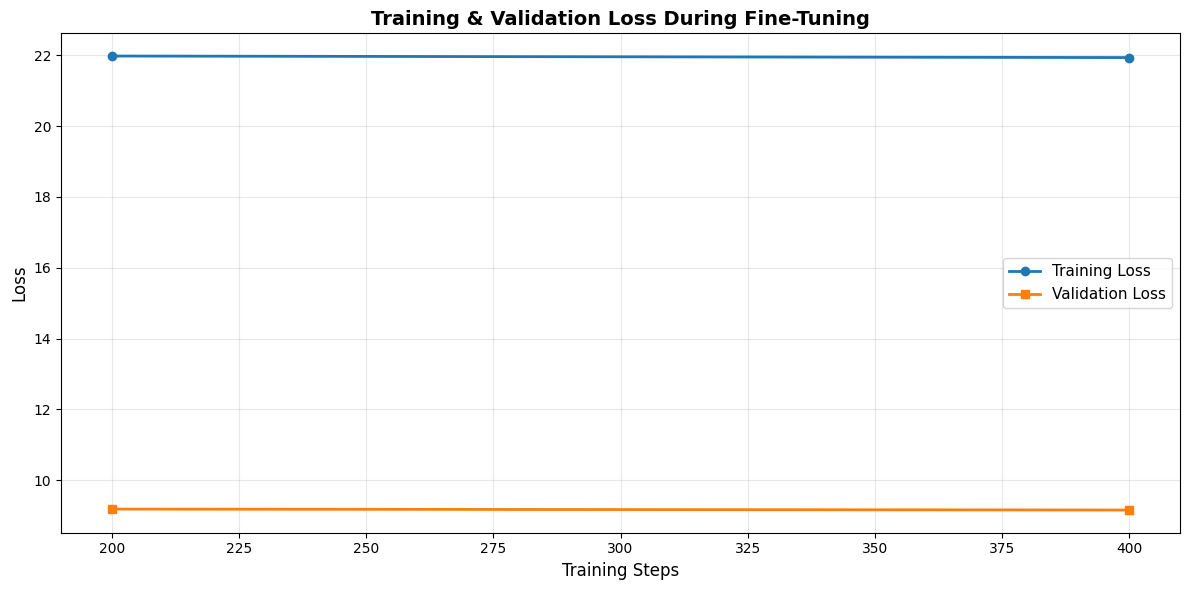


=== LOSS SUMMARY ===
Initial Training Loss: 21.9760
Final Training Loss: 21.9327
Training Loss Reduction: 0.0433 (0.20%)

Initial Validation Loss: 9.1860
Final Validation Loss: 9.1598
Validation Loss Reduction: 0.0262 (0.29%)

Best Validation Loss: 9.1598 (Step 400)


In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract metrics from training history
log_history = trainer.state.log_history

# Separate training and validation metrics
train_steps = []
train_losses = []
val_steps = []
val_losses = []

for log in log_history:
    step = log.get('step')
    
    if 'loss' in log and 'eval_loss' not in log:
        # Training loss (logged every logging_steps)
        train_steps.append(step)
        train_losses.append(log['loss'])
    
    if 'eval_loss' in log:
        # Validation loss (logged every eval_steps)
        val_steps.append(step)
        val_losses.append(log['eval_loss'])

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(train_steps, train_losses, marker='o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(val_steps, val_losses, marker='s', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training & Validation Loss During Fine-Tuning', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== LOSS SUMMARY ===")
print(f"Initial Training Loss: {train_losses[0]:.4f}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Training Loss Reduction: {train_losses[0] - train_losses[-1]:.4f} ({100 * (train_losses[0] - train_losses[-1]) / train_losses[0]:.2f}%)")
print(f"\nInitial Validation Loss: {val_losses[0]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Validation Loss Reduction: {val_losses[0] - val_losses[-1]:.4f} ({100 * (val_losses[0] - val_losses[-1]) / val_losses[0]:.2f}%)")
print(f"\nBest Validation Loss: {min(val_losses):.4f} (Step {val_steps[val_losses.index(min(val_losses))]})")

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [32]:
# Initialize Model
model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B", 
    trust_remote_code=True, 
    device="cuda",
    model_kwargs={
        "torch_dtype": torch.float16,   # Critical for speed/VRAM
        "attn_implementation": "sdpa"   # Faster attention
    }
)

# Load & Merge
model.load_adapter(".adapters/qwen-finetuned-freMTPL")

In [33]:
# Test Model works
print("Model loaded successfully!")
with model.truncate_sentence_embeddings(truncate_dim=64):
    embeddings_truncated = model.encode(["hello there", "hiya"])
assert embeddings_truncated.shape[-1] == 64

Model loaded successfully!


In [34]:
embeddings_truncated

array([[-0.01672  , -0.01264  , -0.01017  , -0.04858  ,  0.003714 ,
        -0.00398  , -0.03497  ,  0.02354  , -0.093    ,  0.01726  ,
         0.000666 , -0.03262  ,  0.1006   , -0.00905  , -0.05026  ,
         0.08026  , -0.02307  ,  0.06696  ,  0.1146   , -0.08044  ,
         0.03348  ,  0.005    , -0.04047  ,  0.1356   ,  0.00064  ,
        -0.00856  , -0.03058  ,  0.10645  ,  0.01512  , -0.01047  ,
         0.01859  ,  0.03485  , -0.00884  ,  0.002657 , -0.03906  ,
        -0.01318  , -0.013535 , -0.002043 , -0.02956  ,  0.0581   ,
        -0.0176   ,  0.02722  ,  0.0714   , -0.0214   , -0.001844 ,
        -0.03107  ,  0.0514   , -0.01325  ,  0.001894 , -0.007545 ,
        -0.03098  , -0.02312  ,  0.0107   ,  0.005646 ,  0.00905  ,
        -0.05283  ,  0.05322  , -0.001682 ,  0.03986  , -0.00925  ,
        -0.0923   ,  0.04456  , -0.02168  ,  0.00821  ],
       [-0.0004325,  0.01307  , -0.0157   , -0.05142  ,  0.03195  ,
        -0.02362  ,  0.00466  ,  0.0919   , -0.07684  ,  0.

Model is outputting embeddings of dim 64

### Check VRAM Usage

In [35]:
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 9.57 GB
Allocated (Active): 6.69 GB
Free (Approx): 6.25 GB
------------------------------


Now want to generate embeddings from data

Ensure model is running on GPU

In [36]:
print(model.device)

cuda:0


In [37]:
import torch

# Define the device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Moving model to: {device}")

# Move the model to GPU
model = model.to(device)

Moving model to: cuda


In [38]:
print("Generating embeddings for GLM...")

# Encode the serialized text for BOTH Train and Test sets
train_embeddings = model.encode(train_df['text_desc'].tolist(), batch_size=64, show_progress_bar=True)
test_embeddings = model.encode(test_df['text_desc'].tolist(), batch_size=64, show_progress_bar=True)


Generating embeddings for GLM...


Batches:   0%|          | 0/7813 [00:00<?, ?it/s]

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

In [40]:
import numpy as np

# Save everything in one single archive
np.savez(
    "embeddings/train_embeddings.npz", 
    X=train_embeddings,           # The Features (Embeddings)
    y=train_df['ClaimNb'].values, # The Target (Counts)
    w=train_df['Exposure'].values # The Weight (Exposure)
)
print("Saved all training data to embeddings/train_embeddings.npz")
np.savez(
    "embeddings/test_embeddings.npz", 
    X=test_embeddings,           # The Features (Embeddings)
    y=test_df['ClaimNb'].values, # The Target (Counts)
    w=test_df['Exposure'].values # The Weight (Exposure)
)

print("Saved all testing data to embeddings/test_embeddings.npz")

Saved all training data to embeddings/train_embeddings.npz
Saved all testing data to embeddings/test_embeddings.npz
